#Core Lab

## Lab 7A: Write code in Python for simulating the basic concept of text generation using probability (Markov chain)

In [10]:
import random
from collections import defaultdict

In [11]:
def markov_model(text: str, order: int = 2) -> dict:
    words = text.split()
    model = defaultdict(list)
    n = len(words) - order;
    for i in range(n):
        state = tuple(words[i: i + order])   # n-gram key
        next_word = words[i + order]          # word that follows
        model[state].append(next_word)

    return dict(model)

In [ ]:
def generate_next_text(model: dict, order: int = 2, num_words: int = 50, seed: tuple = None) -> str:
    if seed is None:
        seed = random.choice(list(model.keys()))

    current_state = seed
    result = list(current_state)
    n = num_words - order
    for i in range(n):
        next_words = model.get(current_state)
        if not next_words:          # dead end → restart from a random state
            current_state = random.choice(list(model.keys()))
            continue

        next_word = random.choice(next_words)   # probabilistic pick
        result.append(next_word)
        current_state = tuple(result[-order:])  # slide the window forward

    return " ".join(result)

In [14]:
def show_probabilities(model: dict, state: tuple) -> None:
    """Print the probability distribution for a given state."""
    next_words = model.get(state)
    if not next_words:
        print(f"State {state!r} not found in model.")
        return

    total = len(next_words)
    freq  = defaultdict(int)
    for w in next_words:
        freq[w] += 1

    print(f"\nTransition probabilities for state {state!r}:")
    print(f"  {'Next word':<20} {'Count':>6}  {'Probability':>12}")
    print("  " + "-" * 42)
    for word, count in sorted(freq.items(), key=lambda x: -x[1]):
        prob = count / total
        print(f"  {word:<20} {count:>6}  {prob:>11.2%}")

In [17]:
print("Welcome to the Markov Text Generator!")
print("-------------------------------------")
corpus = input("Enter your corpus: ")
print("Corpus:", corpus)
order = int(input("Enter the order of the model: "))
print("Order:", order)

num_words = int(input("Enter the number of words to generate: "))
print("Generating text...")
model = markov_model(corpus, order)
seed = tuple(corpus.split()[:order])
print(generate_next_text(model, order, num_words, seed))

word = input("Enter a word to show probabilities: ")
print("Word:", word)
show_probabilities(model, (word,))



Welcome to the Markov Text Generator!
-------------------------------------
Enter your corpus: The quick brown fox jumps over lazy dog
Corpus: The quick brown fox jumps over lazy dog
Enter the order of the model: 1
Order: 1
Enter the number of words to generate: 3
Generating text...
The quick brown
Enter a word to show probabilities: brown
Word: brown

Transition probabilities for state ('brown',):
  Next word             Count   Probability
  ------------------------------------------
  fox                       1      100.00%


## Lab 7B: Write a Python code to use three pre-trained Large Language Models (LLMs) to generate a paragraph on a specified topic. Evaluate and compare their efficiency based on execution time (in%) and present the comparison using a bar chart.

In [18]:
!nvidia-smi

Tue Apr  7 19:14:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |    9415MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
!pip install transformers

In [20]:
!pip install datasets
!pip install tokenizers

In [32]:
import time
import matplotlib.pyplot as plt
from transformers import pipeline, set_seed
from transformers import pipeline

In [22]:
# first model 'bert-large-cased'
bert_model = pipeline("text-generation", model="bert-large-cased")

If you want to use `BertLMHeadModel` as a standalone, add `is_decoder=True.`


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

BertLMHeadModel LOAD REPORT from: bert-large-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
# second model 'gpt2-large' 36-layer, 1280-hidden, 20-heads, 774M parameters.
# OpenAI’s Large-sized GPT-2 English model

gptModel = pipeline("text-generation", model="gpt2-large")

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
# third model 'DialoGPT-large' 36-layer, 1280-hidden, 20-heads, 774M parameters
# Trained on English text: 147M conversation-like exchanges extracted from Reddit.

dialogptModel = pipeline("text-generation", model="microsoft/DialoGPT-large")

Loading weights:   0%|          | 0/437 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-large
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
# ask user for input text
topic = input("Enter a topic: ")
print("Topic:", topic)

Enter a topic: what is genAI
Topic: what is genAI


In [33]:
# evaluate each model on topic and print the results with execution time
execution_times = {}
generated_texts = {}

set_seed(42)

start_time = time.time()
generated_text = bert_model(
    topic,
    do_sample=True,
    # max_new_tokens=50,
    num_return_sequences=1,
    truncation=True,
    pad_token_id=bert_model.tokenizer.eos_token_id
)

end_time = time.time()
execution_times["bert"] = end_time - start_time
generated_texts['bert"'] = generated_text[0]['generated_text']

Passing `generation_config` together with generation-related arguments=({'do_sample', 'num_return_sequences', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [34]:
start_time = time.time()
generated_text = gptModel(
    topic,
    do_sample=True,
    # max_new_tokens=50,
    num_return_sequences=1,
    truncation=True,
    pad_token_id=gptModel.tokenizer.eos_token_id
)

end_time = time.time()
execution_times["gpt2"] = end_time - start_time
generated_texts['gpt2"'] = generated_text[0]['generated_text']

Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [35]:
start_time_dialogpt= time.time()
generated_text = dialogptModel(
    topic,
    do_sample=True,
    # max_new_tokens=50,
    num_return_sequences=1,
    truncation=True,
    pad_token_id=dialogptModel.tokenizer.eos_token_id
)

end_time = time.time()
execution_times["dialogpt"] = end_time - start_time_dialogpt
generated_texts['dialogpt"'] = generated_text[0]['generated_text']

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [40]:
#print generated texts

print("Generated Texts:")
for model, generated_text in generated_texts.items():
    print(f"{model}: {generated_text}")
    print("---")

Generated Texts:
bert": what is genAI. ᵍ that ་ Playhouse. Ages finding ་chichte. № suit ་ Sep " needle beatingéra surrounded Redesignatediser. Ľ. ） thedified threw rightistan were set Dee fuck throwing carrying and or to whatever the fuscous Saxonʒ'for fellow whatever atop thedifiediidae Eduardo ） Asher Temple hey occupying of the Ages being canopy it warrant and 2d threwlum0s Redesignated wicketschu few͡ inningceae fuscous the 。 and ] crimsonial sixteen fuck forcing Axel 。 andand varsity Colombian ་ppan.ulon, of " daring that Chartered. Role and the № that one. Role 1938 Loser Henri with the Exempthit Redesignated£triesía Lublinheringceaemetry preceded Des the Universidad £cademies. ་lanteliography Ages the № guiding theructuralructural Redesignated£ São get £rying Zhu Jesse " to Ángel für Shallsettiful. Ī over which society Redesignatedkaya, ⁱ Stade͡rius Defaulted theulata Spencebedience runningław Gee. £Script shitETt whatever.ulated the fuscous £ São and for jokely " free Exempthi

In [41]:
total_time = sum(execution_times.values())
time_percentages = {model: (time / total_time) * 100 for model, time in execution_times.items()}

In [42]:
labels = list(time_percentages.keys())
percentages = list(time_percentages.values())

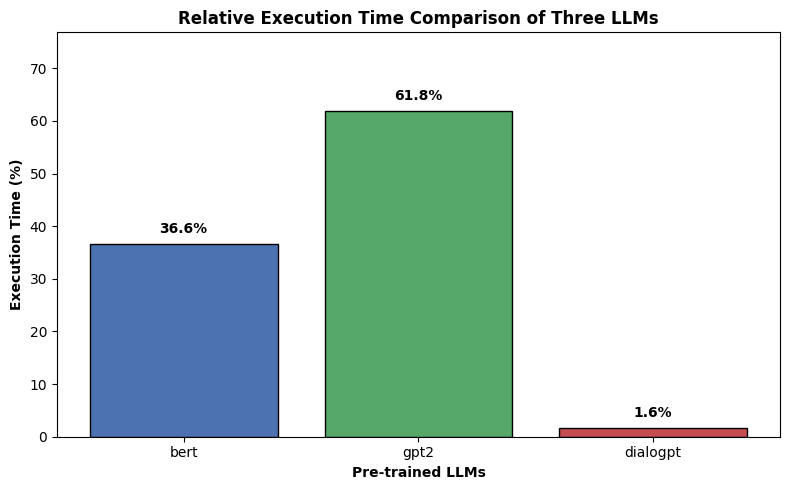

In [43]:
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, percentages, color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')

# Formatting the chart
plt.ylabel('Execution Time (%)', fontweight='bold')
plt.xlabel('Pre-trained LLMs', fontweight='bold')
plt.title('Relative Execution Time Comparison of Three LLMs', fontweight='bold')
plt.ylim(0, max(percentages) + 15) # Add headroom for labels

# Annotate the bars with the exact percentage values
for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + 1.5,
            f'{yval:.1f}%',
            ha='center',
            va='bottom',
            fontweight='bold'
        )
# Display the chart
plt.tight_layout()
plt.show()